In [1]:
import warnings

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import lifelines

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

from tensorflow import keras
from keras import optimizers, initializers

from tensorflow.keras.callbacks import Callback
from tqdm.keras import TqdmCallback
from tqdm import tqdm

from scipy.stats import norm

import thetaflow as thf

2026-03-02 22:34:00.708305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772501640.725775   98238 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772501640.731082   98238 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772501640.744695   98238 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772501640.744724   98238 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772501640.744726   98238 computation_placer.cc:177] computation placer alr

# General framework

Let us consider that for a given statistical model, we can segment the vector of parameters, $\boldsymbol \theta$ into two major sets of parameters:
* $\boldsymbol{\phi}$: Parameters that can be modeled as outputs to a neural network;
* $\boldsymbol{\psi}$: Global parameters modeled as constants for the entire population;

# Linear regression variations

### $\phi = \emptyset, \psi = \{\mu, \sigma^2\}$

Sample mean: 5.059751740373255
Sample variance: 0.7834374442972697


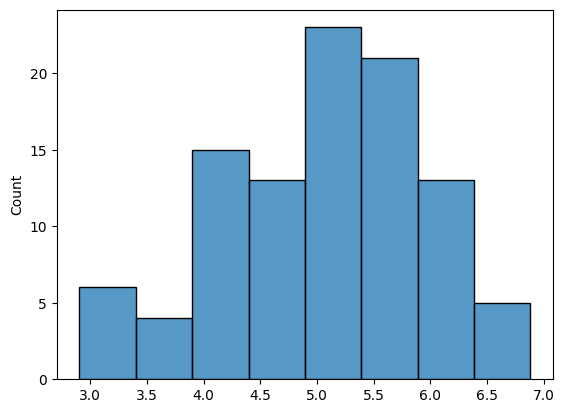

In [2]:
n = 100

mu_0 = 5
sigma2_0 = 1

y0 = np.random.normal(loc = mu_0, scale = np.sqrt(sigma2_0), size = n)

print("Sample mean: {}".format(np.mean(y0)))
print("Sample variance: {}".format(np.var(y0, ddof = 1)))

sns.histplot(x = y0)
plt.show()

In [3]:
regression0_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 1, "init": np.mean(y0)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": np.var(y0)}
}

def regression0_loglikelihood_loss(model, nn_output, data):
    X, y = data

    mu = model.get_variable("mu")
    sigma2 = model.get_variable("sigma2")

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    
    return -loglik

In [4]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression0_model = thf.ModelNN(regression0_parameters, regression0_loglikelihood_loss,
                                    None, None, None,
                                    input_dim = (None, 1), seed = 10)
    
    data0 = [y0]
    
    regression0_mu_before_pretrain = regression0_model.predict("mu")
    regression0_sigma2_before_pretrain = regression0_model.predict("sigma2")
    
    regression0_model.train_model(None, data0,
                                  epochs = 5000, shuffle = True,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-9, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                                  deterministic = True,
                                  verbose = 1)
    
    regression0_mu_after_train = regression0_model.predict("mu")
    regression0_sigma2_after_train = regression0_model.predict("sigma2")

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 300 / 5000 ]  | Loss:  0 | Param Dist:  1.10749127e-12 | Independent Learning rate:  0.01 | Network Learning rate:  0.01 | Speed:  5290  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 3.938 seconds.


In [5]:
df_summary0 = regression0_model.summary()
df_summary0

,index,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,5.064776,0.088294,4.891724,5.237829,0.779526,0.110522,0.562907,0.996145


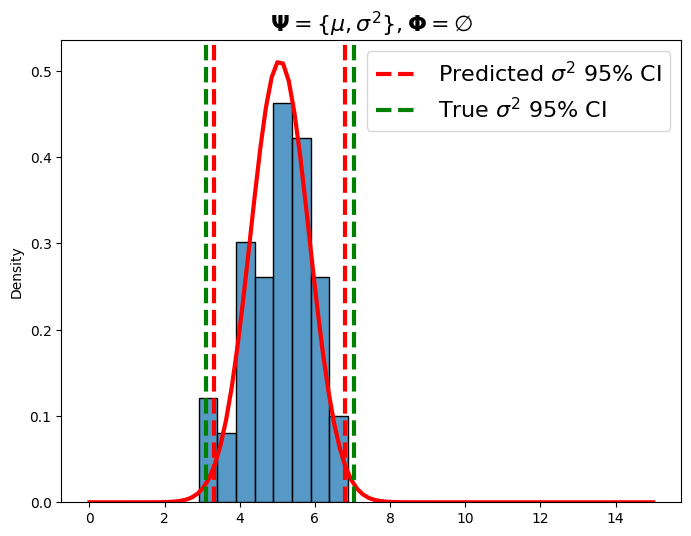

In [6]:
xs = np.linspace(0, 15, 100)

alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var0 = df_summary0["mu_se"]**2 + df_summary0["sigma2"]
y_new_lower0 = df_summary0["mu"] - z_norm * np.sqrt(y_new_var0)
y_new_upper0 = df_summary0["mu"] + z_norm * np.sqrt(y_new_var0)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.histplot(x = y0, stat = "density", ax = ax)
sns.lineplot(x = xs, y = norm.pdf(xs, loc = regression0_mu_after_train, scale = regression0_sigma2_after_train), color = "red", linewidth = 3, ax = ax)
ax.axvline(y_new_lower0[0], color = "red", linewidth = 3, linestyle = "dashed", label = r"Predicted $\sigma^2$ 95% CI")
ax.axvline(y_new_upper0[0], color = "red", linewidth = 3, linestyle = "dashed")

sort_sigma2_0 = sigma2_0
y_new_lower0_true = df_summary0["mu"] - z_norm * np.sqrt( df_summary0["mu_se"]**2 + sort_sigma2_0 )
y_new_upper0_true = df_summary0["mu"] + z_norm * np.sqrt( df_summary0["mu_se"]**2 + sort_sigma2_0 )

ax.axvline(y_new_lower0_true[0], color = "green", linewidth = 3, linestyle = "dashed", label = r"True $\sigma^2$ 95% CI")
ax.axvline(y_new_upper0_true[0], color = "green", linewidth = 3, linestyle = "dashed")
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\mu, \sigma^2\}, \boldsymbol{\Phi} = \emptyset$", fontsize = 16)

plt.show()

### $\phi = \{\mu\}, \psi = \{\sigma^2\}$

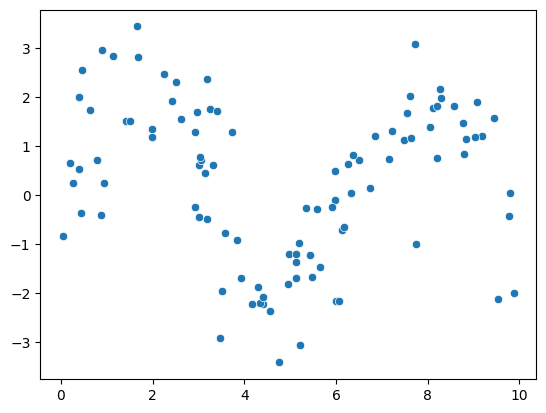

In [7]:
n = 100

sigma2_1 = 1

np.random.seed(10)
x1 = np.random.uniform(low = 0.0, high = 10.0, size = n)

true_f1 = lambda x : 2*np.sin(x)
y1 = true_f1(x1) + np.random.normal(loc = 0.0, scale = np.sqrt(sigma2_1), size = n)

sns.scatterplot(x = x1, y = y1)
plt.show()

In [8]:
regression1_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": np.mean(y1)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": np.var(y1)}
}

def regression1_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2")
    # Simply replaces the linear predictor by the nn_output
    mu = model.get_variable("mu", nn_output)

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

def regression1_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense3 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression1_network_call(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression1_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [9]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression1_model = thf.ModelNN(regression1_parameters, regression1_loglikelihood_loss,
                                      regression1_neural_network, regression1_network_call,
                                      regression1_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    data1 = [y1]
    
    sort_x1 = np.sort(x1)
    regression1_mu_before_pretrain = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_before_pretrain = regression1_model.predict("sigma2")
    
    regression1_model.pre_train_model(x1, data1,
                                      epochs = 500, shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, track_time = True)
    
    regression1_mu_after_pretrain = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_after_pretrain = regression1_model.predict("sigma2")

In [10]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression1_model = thf.ModelNN(regression1_parameters, regression1_loglikelihood_loss,
                                      regression1_neural_network, regression1_network_call,
                                      regression1_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    regression1_model.train_model(x1, data1,
                                  epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-6,
                                  verbose = 1, print_freq = 100)
    
    regression1_mu_after_train = regression1_model.predict(sort_x1)["mu"].numpy().flatten()
    regression1_sigma2_after_train = regression1_model.predict("sigma2")

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 700 / 15000 ]  | Loss:  122.080399 | Param Dist:  5.74134247e-05 | Independent Learning rate:  0.005 | Network Learning rate:  0.005 | Speed:  2750  it/s   
Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 100 / 15000 ]  | Loss:  133.739 | Param Dist:  4.33806417e-05 | Independent Learning rate:  0.005 | Network Learning rate:  0.005 | Speed:  3126  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 1.860 seconds.


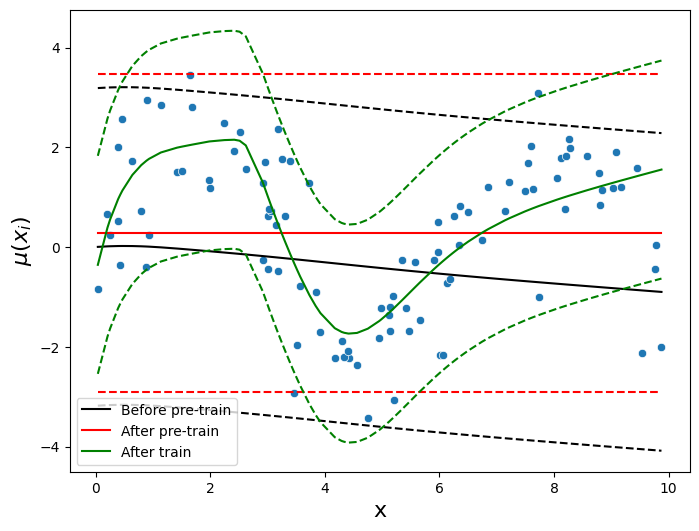

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x1, y = y1)

sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain, ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain - 2*np.sqrt(regression1_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain + 2*np.sqrt(regression1_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain, ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain - 2*np.sqrt(regression1_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain + 2*np.sqrt(regression1_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x1, y = regression1_mu_after_train, ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x1, y = regression1_mu_after_train - 2*np.sqrt(regression1_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_after_train + 2*np.sqrt(regression1_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [12]:
sort_x1 = np.sort(x1)

df_summary1 = regression1_model.summary(sort_x1[:,None])
df_summary1.insert(1, "x", sort_x1)
df_summary1

,index,x,sigma2,sigma2_se,sigma2_lower,sigma2_upper,mu,mu_se,mu_lower,mu_upper
0,1,0.039483,1.194459,0.17117,0.858973,1.529946,-0.357098,0.897956,-2.117059,1.402863
1,2,0.207519,1.194459,0.17117,0.858973,1.529946,0.388126,0.906708,-1.388990,2.165242
2,3,0.253998,1.194459,0.17117,0.858973,1.529946,0.552779,0.917598,-1.245679,2.351237
3,4,0.392818,1.194459,0.17117,0.858973,1.529946,0.958168,0.969209,-0.941447,2.857783
4,5,0.399592,1.194459,0.17117,0.858973,1.529946,0.975056,0.972314,-0.930644,2.880756
...,...,...,...,...,...,...,...,...,...,...
95,96,9.442607,1.194459,0.17117,0.858973,1.529946,1.418759,1.194137,-0.921707,3.759225
96,97,9.533933,1.194459,0.17117,0.858973,1.529946,1.447267,1.206776,-0.917970,3.812505
97,98,9.770807,1.194459,0.17117,0.858973,1.529946,1.520703,1.239547,-0.908764,3.950171
98,99,9.788191,1.194459,0.17117,0.858973,1.529946,1.526068,1.241951,-0.908112,3.960248


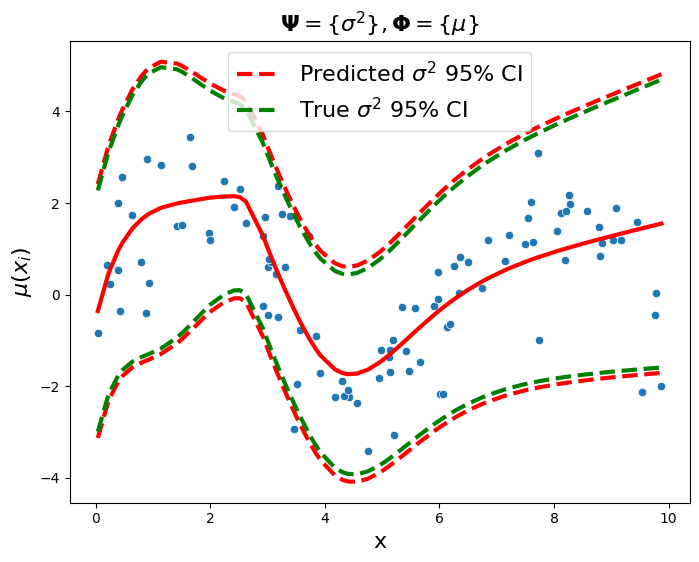

In [13]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var1 = df_summary1["mu_se"]**2 + df_summary1["sigma2"]
y_new_lower1 = df_summary1["mu"] - z_norm * np.sqrt(y_new_var1)
y_new_upper1 = df_summary1["mu"] + z_norm * np.sqrt(y_new_var1)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x1, y = y1)
sns.lineplot(x = sort_x1, y = df_summary1["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x1, y = y_new_lower1, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x1, y = y_new_upper1, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_1 = sigma2_1
y_new_lower1_true = df_summary1["mu"] - z_norm * np.sqrt( df_summary1["mu_se"]**2 + sort_sigma2_1 )
y_new_upper1_true = df_summary1["mu"] + z_norm * np.sqrt( df_summary1["mu_se"]**2 + sort_sigma2_1 )

# sns.lineplot(x = sort_x2, y = y_new_lower2_true, color = "purple", linestyle = "dashed", ax = ax)
# sns.lineplot(x = sort_x2, y = y_new_upper2_true, color = "purple", linestyle = "dashed", ax = ax)
sns.lineplot(x = sort_x1, y = y_new_lower1_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x1, y = y_new_upper1_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\sigma^2\}, \boldsymbol{\Phi} = \{\mu\}$", fontsize = 16)

plt.show()

Just to exemplify the method variable_function_covariance as a general way of obtaining the covariance structure of any function of the parameters, we consider the transformation
\begin{equation*}
f(\mu, \sigma^2) = [\mu, 2\sigma^2]
\end{equation*}
Of course, we expect to see a $2 \times 2$ covariance matrix whose diagonal is equivalent to $\text{Var}[\widehat{\mu}]$ and $4\text{Var}[\widehat{\sigma}^2]$.

In [14]:
def fun(model, nn_output, data):
    X, y = data
    mu = model.get_variable("mu", nn_output)
    sigma2 = model.get_variable("sigma2")
    return tf.concat([mu, 2*tf.tile(sigma2[:,None], (tf.size(mu), 1))], axis = -1)

fun_cov = regression1_model.variable_function_covariance(fun, sort_x1[:5], data1)
fun_cov

<tf.Tensor: shape=(5, 2, 2), dtype=float32, numpy=
array([[[0.80632466, 0.00786679],
        [0.00786684, 0.11719611]],

       [[0.8221201 , 0.00845543],
        [0.00845548, 0.11719611]],

       [[0.84198546, 0.00866928],
        [0.00866933, 0.11719611]],

       [[0.93936586, 0.00937236],
        [0.00937242, 0.11719611]],

       [[0.9453939 , 0.00940768],
        [0.00940773, 0.11719611]]], dtype=float32)>

In [15]:
theta_cov = regression1_model.covariance_output(sort_x1[:5])
theta_cov

<tf.Tensor: shape=(5, 2, 2), dtype=float32, numpy=
array([[[0.02929903, 0.00393342],
        [0.00393339, 0.80632466]],

       [[0.02929903, 0.00422774],
        [0.00422771, 0.8221201 ]],

       [[0.02929903, 0.00433467],
        [0.00433464, 0.84198546]],

       [[0.02929903, 0.00468621],
        [0.00468618, 0.93936586]],

       [[0.02929903, 0.00470387],
        [0.00470384, 0.9453939 ]]], dtype=float32)>

In [16]:
theta_cov[:,0,0]*4

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.11719611, 0.11719611, 0.11719611, 0.11719611, 0.11719611],
      dtype=float32)>

Indeed, we can see that the variances match exactly to their expected values.

### $\phi = \{\sigma^2\}, \psi = \{\mu\}$

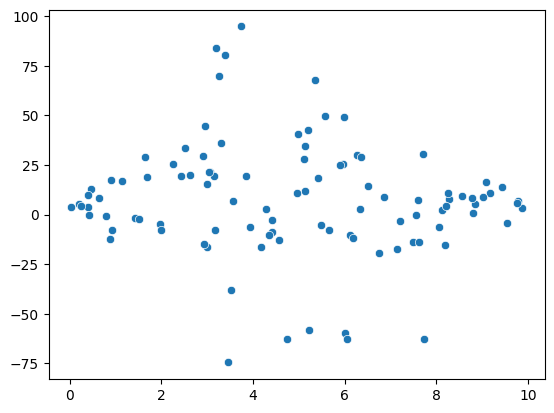

In [17]:
n = 100

mu = 5

np.random.seed(10)
x2 = np.random.uniform(low = 0.0, high = 10.0, size = n)

# true_f = lambda x : 1000 * 1/np.sqrt(2*np.pi*x) * np.exp(-(x-5)**2/(2*2))
def true_sigma2_2(x):
    y = np.zeros_like(x)
    y0 = 50
    y[x <= 5] = y0/5 * x[x <= 5]
    y[x > 5] = -y0/5 * x[x > 5] + 2*y0
    return 1+y**2

sigma2_2 = true_sigma2_2(x2)

y2 = mu + np.random.normal(loc = 0, scale = np.sqrt(sigma2_2))

sns.scatterplot(x = x2, y = y2)
plt.show()

In [18]:
regression2_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 1, "init": np.mean(y2)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1500.0}
}

def regression2_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2", nn_output)
    mu = model.get_variable("mu")

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

def regression2_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense3 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression2_network_call(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression2_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [19]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression2_model = thf.ModelNN(regression2_parameters, regression2_loglikelihood_loss,
                                      regression2_neural_network, regression2_network_call,
                                      regression2_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    # Remove the column of ones (already handled by tensorflow)
    data2 = [y2]
    sort_x2 = np.sort(x2)
    
    regression2_mu_before_pretrain = regression2_model.predict("mu")
    regression2_sigma2_before_pretrain = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()
    
    regression2_model.pre_train_model(x2, data2,
                                      epochs = 500, shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, track_time = True)
    
    regression2_mu_after_pretrain = regression2_model.predict("mu")
    regression2_sigma2_after_pretrain = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()

In [20]:
with tf.device("/CPU:0"):
    regression2_model.train_model(x2, data2,
                                  epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-6,
                                  deterministic = True,
                                  verbose = 1, print_freq = 100)
    
    regression2_mu_after_train = regression2_model.predict("mu")
    regression2_sigma2_after_train = regression2_model.predict(sort_x2)["sigma2"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1600 / 15000 ]  | Loss:  427.632202 | Param Dist:  0.00195281149 | Independent Learning rate:  0.005 | Network Learning rate:  0.005 | Speed:  2771  it/s    
Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 2500 / 15000 ]  | Loss:  546.332153 | Param Dist:  9.92131536e-05 | Independent Learning rate:  0.00125 | Network Learning rate:  0.00125 | Speed:  2944  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 2.879 seconds.


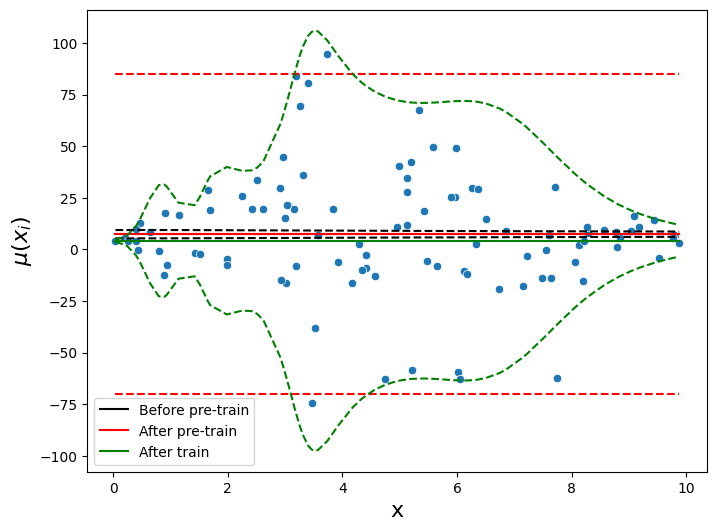

In [21]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x2, y = y2)

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ), ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_before_pretrain, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ), ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_pretrain, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ), ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ) - 2*np.sqrt(regression2_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x2, y = np.repeat( regression2_mu_after_train, len(sort_x2) ) + 2*np.sqrt(regression2_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [22]:
df_summary2 = regression2_model.summary(sort_x2[:,None])
df_summary2.insert(1, "x", sort_x2)
df_summary2

,index,x,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,0.039483,4.209007,0.261139,3.697184,4.72083,0.071563,0.229368,-0.377991,0.521116
1,2,0.207519,4.209007,0.261139,3.697184,4.72083,1.031095,3.394652,-5.622301,7.684491
2,3,0.253998,4.209007,0.261139,3.697184,4.72083,2.019923,6.676867,-11.066496,15.106342
3,4,0.392818,4.209007,0.261139,3.697184,4.72083,12.060843,39.902393,-66.146408,90.268097
4,5,0.399592,4.209007,0.261139,3.697184,4.72083,13.035434,43.108242,-71.455170,97.526031
...,...,...,...,...,...,...,...,...,...,...
95,96,9.442607,4.209007,0.261139,3.697184,4.72083,28.534687,21.636295,-13.871674,70.941048
96,97,9.533933,4.209007,0.261139,3.697184,4.72083,24.805073,19.078732,-12.588554,62.198700
97,98,9.770807,4.209007,0.261139,3.697184,4.72083,17.361147,13.851249,-9.786802,44.509094
98,99,9.788191,4.209007,0.261139,3.697184,4.72083,16.918468,13.534007,-9.607698,43.444633


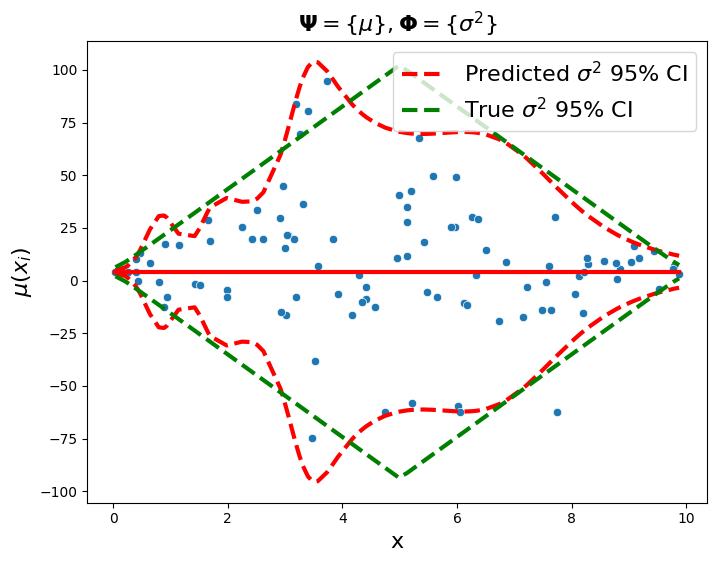

In [23]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var = df_summary2["mu_se"]**2 + df_summary2["sigma2"]
y_new_lower = df_summary2["mu"] - z_norm * np.sqrt(y_new_var)
y_new_upper = df_summary2["mu"] + z_norm * np.sqrt(y_new_var)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x2, y = y2)
sns.lineplot(x = sort_x2, y = df_summary2["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x2, y = y_new_lower, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x2, y = y_new_upper, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_2 = true_sigma2_2(sort_x2)
y_new_lower2_true = df_summary2["mu"] - z_norm * np.sqrt( df_summary2["mu_se"]**2 + sort_sigma2_2 )
y_new_upper2_true = df_summary2["mu"] + z_norm * np.sqrt( df_summary2["mu_se"]**2 + sort_sigma2_2 )

sns.lineplot(x = sort_x2, y = y_new_lower2_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x2, y = y_new_upper2_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \{\mu\}, \boldsymbol{\Phi} = \{\sigma^2\}$", fontsize = 16)

plt.show()

### $\phi = \{\mu, \sigma^2\}, \psi = \emptyset$

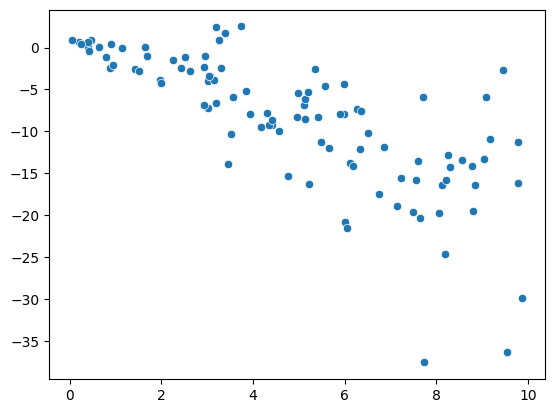

In [24]:
n = 100

np.random.seed(10)
x3 = np.random.uniform(low = 0.0, high = 10.0, size = n)

true_mu_3 = lambda x : -2*x + 1
true_sigma2_3 = lambda x : x**2

mu_3 = true_mu_3(x3)
sigma2_3 = true_sigma2_3(x3)

y3 = mu_3 + np.random.normal(loc = 0, scale = np.sqrt(sigma2_3))

sns.scatterplot(x = x3, y = y3)
plt.show()

In [25]:
regression3_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": np.mean(y3)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": np.var(y3)}
}

def regression3_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2", nn_output)
    mu = model.get_variable("mu", nn_output)

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )

    return -loglik

def regression3_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 2, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression3_network_call(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return model.dense3(x)

def regression3_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    return x

In [26]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression3_model = thf.ModelNN(regression3_parameters, regression3_loglikelihood_loss,
                                    regression3_neural_network, regression3_network_call,
                                    regression3_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    # Remove the column of ones (already handled by tensorflow)
    data3 = [y3]
    sort_x3 = np.sort(x3)
    
    regression3_mu_before_pretrain = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_before_pretrain = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()
    
    regression3_model.pre_train_model(x3, data3,
                                      epochs = 500, shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = 1, track_time = True)
    
    regression3_mu_after_pretrain = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_after_pretrain = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()

In [27]:
with tf.device("/CPU:0"):
    regression3_model.train_model(x3, data3,
                                  epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-6,
                                  deterministic = True,
                                  verbose = 1, print_freq = 100)
    
    regression3_mu_after_train = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_after_train = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 3100 / 15000 ]  | Loss:  4296.15234 | Param Dist:  0.000424756552 | Independent Learning rate:  0.01 | Network Learning rate:  0.0025 | Speed:  2804  it/s   
Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 200 / 15000 ]  | Loss:  4082.08984 | Param Dist:  3.82508915e-05 | Independent Learning rate:  0.01 | Network Learning rate:  0.0025 | Speed:  2822  it/s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 2.557 seconds.


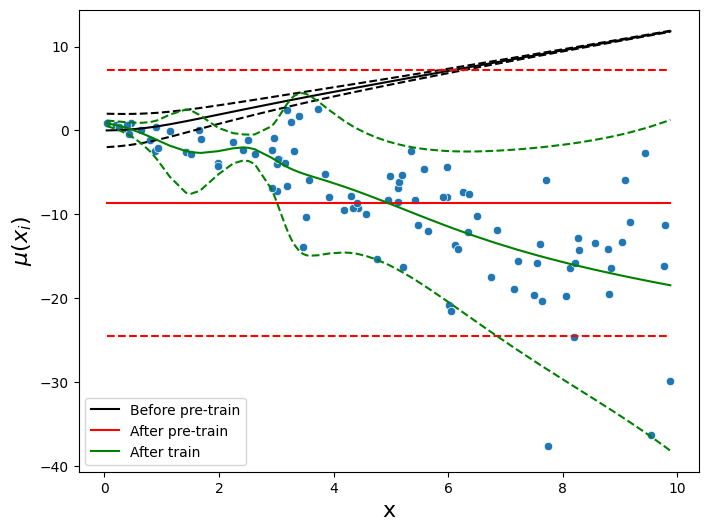

In [28]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x3, y = y3)

sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain, ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain - 2*np.sqrt(regression3_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain + 2*np.sqrt(regression3_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain, ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain - 2*np.sqrt(regression3_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain + 2*np.sqrt(regression3_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x3, y = regression3_mu_after_train, ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x3, y = regression3_mu_after_train - 2*np.sqrt(regression3_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_after_train + 2*np.sqrt(regression3_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [29]:
df_summary3 = regression3_model.summary(sort_x3[:,None])
df_summary3.insert(1, "x", sort_x3)
df_summary3

,index,x,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,0.039483,0.850931,0.366852,0.131914,1.569948,0.027389,0.018496,-0.008863,0.063640
1,2,0.207519,0.631228,0.285982,0.070714,1.191742,0.052215,0.029533,-0.005668,0.110099
2,3,0.253998,0.551732,0.263109,0.036047,1.067417,0.064465,0.034276,-0.002715,0.131645
3,4,0.392818,0.285266,0.210043,-0.126412,0.696943,0.120712,0.052785,0.017256,0.224168
4,5,0.399592,0.271175,0.208123,-0.136738,0.679088,0.124421,0.053877,0.018824,0.230018
...,...,...,...,...,...,...,...,...,...,...
95,96,9.442607,-17.869102,4.721825,-27.123711,-8.614495,82.328590,228.012680,-364.568085,529.225281
96,97,9.533933,-17.992165,4.763050,-27.327572,-8.656758,85.187256,237.771927,-380.837158,551.211670
97,98,9.770807,-18.304949,4.868145,-27.846340,-8.763558,93.223679,265.353455,-426.859558,613.306946
98,99,9.788191,-18.327564,4.875763,-27.883884,-8.771244,93.851990,267.518402,-430.474487,618.178467


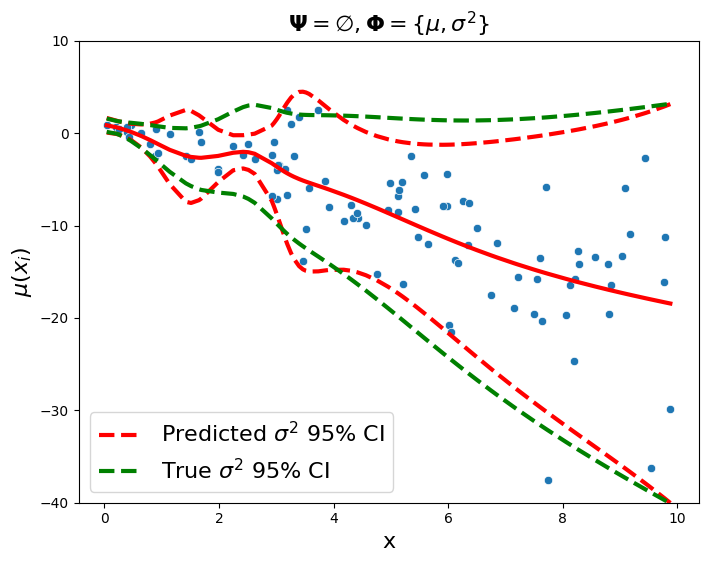

In [30]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var3 = df_summary3["mu_se"]**2 + df_summary3["sigma2"]
y_new_lower3 = df_summary3["mu"] - z_norm * np.sqrt(y_new_var3)
y_new_upper3 = df_summary3["mu"] + z_norm * np.sqrt(y_new_var3)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x3, y = y3)
sns.lineplot(x = sort_x3, y = df_summary3["mu"], color = "red", ax = ax, linewidth = 3)
sns.lineplot(x = sort_x3, y = y_new_lower3, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"Predicted $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x3, y = y_new_upper3, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_3 = true_sigma2_3(sort_x2)
y_new_lower3_true = df_summary3["mu"] - z_norm * np.sqrt( df_summary3["mu_se"]**2 + sort_sigma2_3 )
y_new_upper3_true = df_summary3["mu"] + z_norm * np.sqrt( df_summary3["mu_se"]**2 + sort_sigma2_3 )

sns.lineplot(x = sort_x2, y = y_new_lower3_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
sns.lineplot(x = sort_x2, y = y_new_upper3_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.set_ylim(-40,10)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\Psi} = \emptyset, \boldsymbol{\Phi} = \{\mu, \sigma^2\}$", fontsize = 16)

plt.show()